# Credit Card Fraud Detection - Exploratory Data Analysis (EDA)

## Dataset

This project uses the **Credit Card Fraud Detection** dataset from **Kaggle**. The dataset contains real credit card transactions made by European cardholders over two days.

### Dataset Information
- **Source:** Kaggle
- **Total Transactions:** 284,807
- **Features:** 31

### Feature Information
- The features **V1 to V28** have already been transformed using **Principal Component Analysis (PCA)** to protect customer privacy.
- The **Time** and **Amount** features are the original values and are not transformed.
- The **Class** column is the target variable:
  - **0 = Genuine Transaction**
  - **1 = Fraudulent Transaction**

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('../data/creditcard.csv')
print("Shape : ", df.shape)
df.head(10)

Shape :  (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [20]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [21]:
print("Data type :\n", df.dtypes)
print("\nNull values :\n", df.isnull().sum())
print("\nTotal null values :", df.isnull().sum().sum())

Data type :
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Null values :
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total null va

### Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an important step in every machine learning project. It helps us understand the structure of the dataset, identify important patterns, detect missing values and outliers, and analyze the distribution of different features.

In this project, EDA is performed to understand the behavior of genuine and fraudulent credit card transactions. By analyzing the data visually, we can identify class imbalance, transaction amount patterns, and transaction time patterns. These insights help us select suitable preprocessing techniques and build a more effective fraud detection model.

The class distribution graph shows the number of genuine and fraudulent transactions in the dataset. This analysis helps us understand whether the dataset is balanced or imbalanced. Since machine learning models can be affected by class imbalance, it is important to examine the distribution of both classes before training the model.

Class Distribution :
Class
0    284315
1       492
Name: count, dtype: int64
Fraudulent Transactions : 0.173 %


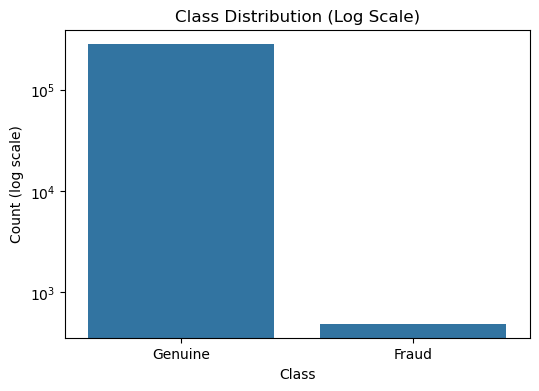

In [22]:
print("Class Distribution :")
print(df['Class'].value_counts())
print("Fraudulent Transactions :",round(df['Class'].value_counts()[1] / len(df) * 100, 3), "%")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)

plt.yscale('log')
plt.minorticks_off()
plt.xticks([0,1], ['Genuine', 'Fraud'])
plt.title('Class Distribution (Log Scale)')
plt.ylabel('Count (log scale)')
plt.show()

#### Observations

- The dataset contains **284,315 genuine transactions** and **492 fraudulent transactions**.
- Fraud transactions account for only **0.173%** of the total transactions.
- The dataset is **highly imbalanced**, with genuine transactions making up almost all of the data.
- Due to this imbalance, accuracy alone is not a reliable evaluation metric. Metrics such as **Precision, Recall, and F1-score** are more suitable for evaluating the fraud detection model.

### Feature Correlation with Fraud

Correlation analysis helps identify the relationship between each feature and the target variable (`Class`). Features with higher positive or negative correlation are generally more informative for distinguishing fraudulent transactions from genuine ones.

In this visualization:
- **Positive correlation** indicates the feature is more associated with fraudulent transactions.
- **Negative correlation** indicates the feature is more associated with genuine transactions.
- Features with correlations close to **zero** have little linear relationship with the target.

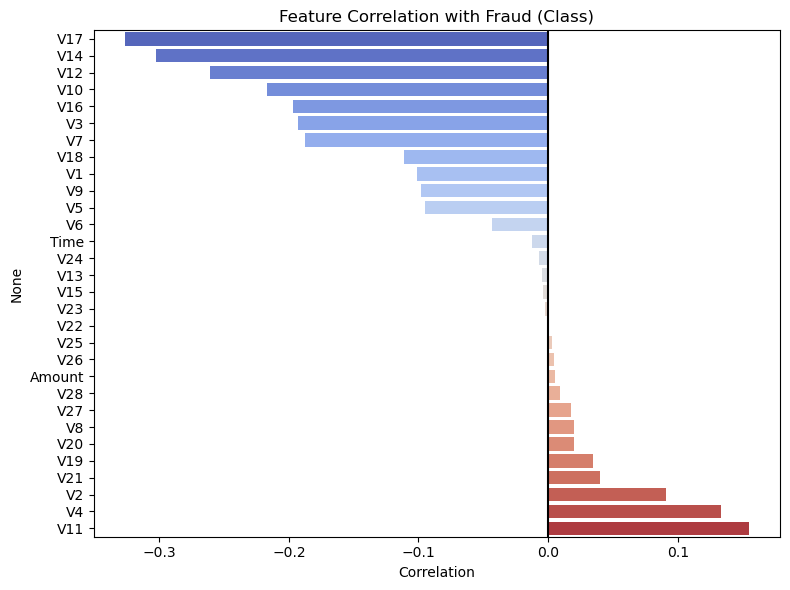

In [31]:
plt.figure(figsize=(8, 6))

corr = df.corr()['Class'].drop('Class').sort_values()

sns.barplot(
    x=corr.values,
    y=corr.index,
    hue=corr.index,
    palette='coolwarm',
    legend=False
)

plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Correlation')
plt.axvline(x=0, color='black')
plt.tight_layout()
plt.show()

### Observations

- The correlation values range approximately from **-0.32 to +0.16**, indicating that no single feature has a very strong linear relationship with the target variable (`Class`).
- **V17** has the strongest negative correlation (around **-0.32**), followed by **V14**, **V12**, **V10**, **V16**, **V3**, and **V7**. These features are more associated with genuine transactions.
- **V11** has the strongest positive correlation (around **+0.15**), followed by **V4** and **V2**. These features are more associated with fraudulent transactions.
- Features such as **V22, V23, V15, V13, V24, Time,** and **Amount** have correlation values close to **zero**, indicating a weak linear relationship with both genuine and fraudulent transactions.
- Since most features have only weak to moderate correlations individually, relying on a single feature is not sufficient for fraud detection.
- Machine learning models can combine information from multiple features to detect complex patterns, resulting in more accurate fraud detection than using correlation alone.

### Transaction Amount Analysis

Analyze the distribution of transaction amounts for genuine and fraudulent transactions to identify spending patterns and understand whether fraudsters tend to make small or large transactions.

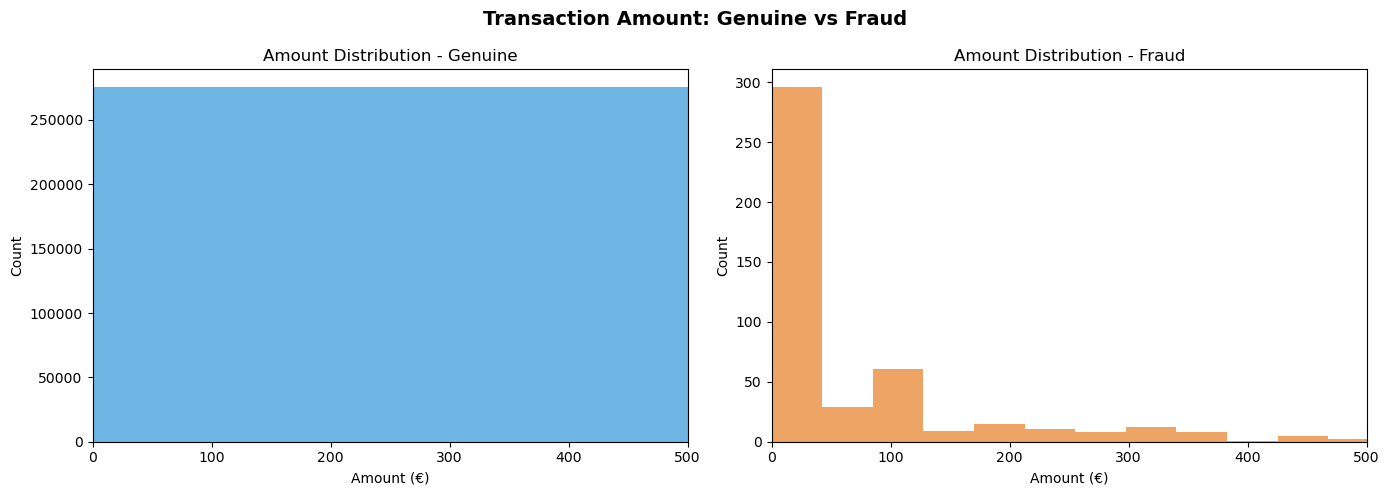

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Amount'], 
             bins=50, color='#3498db', alpha=0.7)
axes[0].set_title('Amount Distribution - Genuine')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 500)

axes[1].hist(df[df['Class']==1]['Amount'], 
             bins=50, color='#e67e22', alpha=0.7)
axes[1].set_title('Amount Distribution - Fraud')
axes[1].set_xlabel('Amount (€)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 500)

plt.suptitle('Transaction Amount: Genuine vs Fraud', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
print("AMOUNT STATISTICS : ")
print(f"\nGenuine - Mean  : €{df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Genuine - Max   : €{df[df['Class']==0]['Amount'].max():.2f}")
print(f"Genuine - Median: €{df[df['Class']==0]['Amount'].median():.2f}")
print(f"\nFraud   - Mean  : €{df[df['Class']==1]['Amount'].mean():.2f}")
print(f"Fraud   - Max   : €{df[df['Class']==1]['Amount'].max():.2f}")
print(f"Fraud   - Median: €{df[df['Class']==1]['Amount'].median():.2f}")

AMOUNT STATISTICS : 

Genuine - Mean  : €88.29
Genuine - Max   : €25691.16
Genuine - Median: €22.00

Fraud   - Mean  : €122.21
Fraud   - Max   : €2125.87
Fraud   - Median: €9.25


#### Amount Insight

- Fraud transactions generally have smaller amounts than genuine transactions.
- The median fraud amount (€9.25) is lower than the median genuine amount (€22.00).
- Most fraud cases occur in low-value transactions, which may help fraudsters avoid detection.
- Although most fraud amounts are small, a few large fraud transactions increase the average fraud amount.
- This suggests that fraudsters often start with small transactions and sometimes make larger transactions later.

### Transaction Time Analysis

Analyze the distribution of genuine and fraudulent transactions over time to identify daily transaction patterns and compare day and night activity.

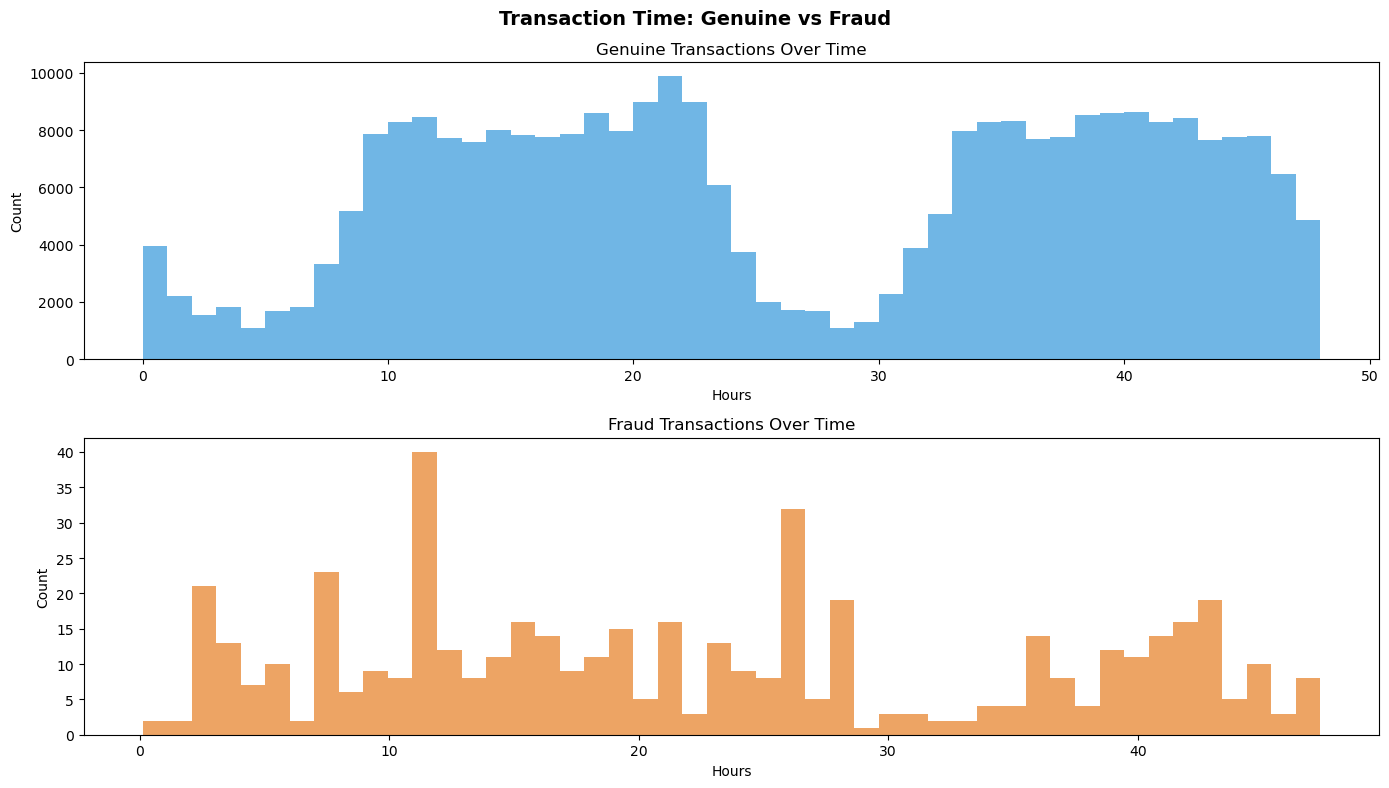

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].hist(df[df['Class']==0]['Time']/3600,
             bins=48, color='#3498db', alpha=0.7)
axes[0].set_title('Genuine Transactions Over Time')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Count')

axes[1].hist(df[df['Class']==1]['Time']/3600,
             bins=48, color='#e67e22', alpha=0.7)
axes[1].set_title('Fraud Transactions Over Time')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Count')

plt.suptitle('Transaction Time: Genuine vs Fraud', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Time Insight

- The dataset contains transactions from 2 days (48 hours).
- Genuine transactions are higher during the daytime and lower at night.
- Fraud transactions are random across all hours — no sleep pattern, suggesting automated/bot activity.
- Since fraud also occurs at night, transaction time can help the model detect suspicious activity.